In [1]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset

from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer 
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance
from gsnn.interpret.NoiseTunnel import NoiseTunnel 

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests 

import seaborn as sbn 

%load_ext autoreload
%autoreload 2 

/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
  warnings.warn(msg)


In [2]:
mds_preds = pd.read_csv('mds_predictions.csv', low_memory=False) 
mds_preds.head() 

,id,inhibitor_1,inhibitor_2,yhat
0,MLL_00003,jq1,jq1,-0.752375
1,MLL_00009,jq1,jq1,-0.906530
2,MLL_09939,jq1,jq1,-0.927727
3,MLL_09941,jq1,jq1,-0.771498
4,MLL_09942,jq1,jq1,-0.969653


In [56]:
min_lls_n = 3

lls_muts = pd.read_excel('lls_mds_clin_muts-09-12-2025.xlsx')
lls_muts = lls_muts[lls_muts.n >= min_lls_n]
lls_muts.head(25) 

,gene_name,n
0,TP53,16
1,ASXL1,15
2,TET2,15
3,CEBPA,10
4,DNMT3A,9
5,STAG2,9
6,RUNX1,9
7,CBL,8
8,EZH2,8
9,BCOR,8


In [57]:
# need mds muts 
mds_muts = pd.read_excel('../../data/evansmds/805_data_20250107.xlsx') 
mds_muts.head() 

,MLL ID,Gender 1=female;2=male,Age,Final Diagnosis,Status EN,Clinical Status EN,sample date,Analyses,WBC,HB,...,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2
0,MLL_10694,2,27.0,MDS RA (nach WHO),Primary diagnosis,Primary diagnosis,2005-09-22,ZCFMI,1000.0,8.5,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
1,MUC_00041,2,46.0,MDS RAEB-1 (nach WHO),Primary diagnosis,Primary diagnosis,2005-09-23,ZCFM,2900.0,7.4,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,POSITIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
2,MLL_54186,1,82.0,MDS RAEB-2 (nach WHO),Primary diagnosis,Primary diagnosis,2005-10-13,ZCMI,NaN,NaN,...,NEGATIVE,NEGATIVE,POSITIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
3,MLL_10702,2,65.7,MDS RA (nach WHO),Primary diagnosis,Primary diagnosis,2005-11-21,ZCFMI,3200.0,13.0,...,NEGATIVE,NEGATIVE,POSITIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE
4,MUC_00201,1,34.7,"MDS, 5q- Syndrom (nach WHO)",Primary diagnosis,Primary diagnosis,2006-01-06,ZCFMI,3320.0,9.4,...,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NaN,NEGATIVE,NaN,NEGATIVE


In [58]:
# concept, for a given subgroup defined by a set of mds ids (e.g., {MLL_00003, MLL_00004, MLL_00005}) 
# we create two groups: 
# those in subgroup, and those not in subgroup  
# for each drug in the dataset, we can rank by the difference in predicted response between the two groups (So we're looking for differences in performance in the subgroup) 


In [59]:
# filter to drugs that  have strong predictive performance in MDS 

gsnn_res = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/gsnn/stratified_results.csv')
gsnn_res = gsnn_res[lambda x: x.drug_combination != 'overall']
gsnn_res = gsnn_res[lambda x: x.pearson_r > 0.4]
gsnn_res = gsnn_res.assign(inhibitor_1 = [x if '+' not in x else x.split('+')[0] for x in gsnn_res.drug_combination])
gsnn_res = gsnn_res.assign(inhibitor_2 = [None if '+' not in x else x.split('+')[1] for x in gsnn_res.drug_combination])

high_perf_inhibitor_candidates = gsnn_res[['inhibitor_1', 'inhibitor_2']].drop_duplicates().reset_index(drop=True)
high_perf_inhibitor_candidates.shape

(59, 2)

In [60]:
def eval_subgroup(preds, subgroup_ids, inhibitors, subgroup_name, min_sample_size=3): 

    subgroup_res = {'drug1':[] ,'drug2':[], 'subgroup_y_mean':[], 'subgroup_y_std':[], 'rest_y_mean':[], 'rest_y_std':[], 'pval':[], 'tstat':[], 'subgroup_n':[]}

    for ii, row in inhibitors.iterrows(): 
        print(f'progress: {ii}/{len(inhibitors)}', end='\r')

        tmp = preds[lambda x: (x.inhibitor_1 == row.inhibitor_1)]
        if type(row.inhibitor_2) != str: # then it's nan
            tmp = tmp[lambda x: x.inhibitor_2.isna()] # check for nan 
        else: 
            tmp = tmp[lambda x: x.inhibitor_2 == row.inhibitor_2]

        subgroup_preds = tmp[lambda x: x.id.isin(subgroup_ids)].yhat.values
        rest_preds = tmp[lambda x: ~x.id.isin(subgroup_ids)].yhat.values

         # Validate sample sizes
        if len(subgroup_preds) < min_sample_size or len(rest_preds) < min_sample_size:
            continue
        
        # Perform statistical test
        ttest = ttest_ind(subgroup_preds, rest_preds, equal_var=False)

        subgroup_res['drug1'].append(row.inhibitor_1)
        subgroup_res['drug2'].append(row.inhibitor_2)
        subgroup_res['subgroup_y_mean'].append(subgroup_preds.mean())
        subgroup_res['subgroup_y_std'].append(subgroup_preds.std())
        subgroup_res['rest_y_mean'].append(rest_preds.mean())
        subgroup_res['rest_y_std'].append(rest_preds.std())
        subgroup_res['pval'].append(ttest.pvalue)
        subgroup_res['tstat'].append(ttest.statistic)
        subgroup_res['subgroup_n'].append(len(subgroup_preds))

    subgroup_res = pd.DataFrame(subgroup_res)
    subgroup_res = subgroup_res.assign(mut_subgroup = subgroup_name)
    subgroup_res = subgroup_res.assign(mean_diff = lambda x: x.subgroup_y_mean - x.rest_y_mean)  # resistant is positive, sensitive is negative 
    
    return subgroup_res


In [61]:
valid_groups = set(lls_muts.gene_name.unique().tolist()).intersection(set(mds_muts.columns.tolist()))

res = []
for i, gene in enumerate(valid_groups):  
    print(f'progress: {i}/{len(valid_groups)} [gene: {gene}]')
    subgroup_ids = mds_muts[lambda x: x[gene] == 'POSITIVE']['MLL ID'].unique().tolist() 
    res.append(eval_subgroup(mds_preds, subgroup_ids, high_perf_inhibitor_candidates, gene))

res = pd.concat(res)
res = res.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res.head() 


progress: 0/18 [gene: RUNX1]
progress: 1/18 [gene: EZH2]
progress: 2/18 [gene: DNMT3A]
progress: 3/18 [gene: BCOR]
progress: 4/18 [gene: NOTCH1]
progress: 5/18 [gene: CEBPA]
progress: 6/18 [gene: TET2]
progress: 7/18 [gene: U2AF1]
progress: 8/18 [gene: NF1]
progress: 9/18 [gene: SRSF2]
progress: 10/18 [gene: SETBP1]
progress: 11/18 [gene: ASXL1]
progress: 12/18 [gene: STAG2]
progress: 13/18 [gene: SF3B1]
progress: 14/18 [gene: TP53]
progress: 15/18 [gene: DDX41]
progress: 16/18 [gene: KRAS]
progress: 17/18 [gene: CBL]


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr
0,17-aag (tanespimycin),None,-0.463708,0.252088,-0.507307,0.195524,0.212393,1.259925,57.0,RUNX1,0.043599,0.478967
1,at7519,None,-0.616727,0.178733,-0.665146,0.178816,0.056599,1.940075,57.0,RUNX1,0.048419,0.218488
2,axitinib (ag-013736),None,0.233517,0.253037,0.172442,0.222594,0.085717,1.745300,57.0,RUNX1,0.061075,0.291664
3,bosutinib (ski-606),None,0.386054,0.312306,0.258363,0.289875,0.004468,2.945406,57.0,RUNX1,0.127691,0.037008
4,ci-1040 (pd184352),None,0.237448,0.237678,0.198364,0.193026,0.236596,1.194931,57.0,RUNX1,0.039084,0.508882


In [62]:
#res.to_csv('mds_subgroup_predictions_single_agents.csv', index=False)

In [63]:
res.sort_values('tstat', ascending=True)[lambda x: x.fdr < 0.05].head(20).style.hide()

drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr
otx-015,None,-1.000383,0.211172,-0.892591,0.177855,0.000000,-6.106502,182.000000,TET2,-0.107792,0.000003
trametinib (gsk1120212),None,-1.052013,0.349188,-0.548111,0.338388,0.000027,-5.706693,17.000000,KRAS,-0.503902,0.001002
jq1,None,-0.858132,0.190837,-0.781696,0.161692,0.000003,-4.785476,182.000000,TET2,-0.076435,0.000223
at7519,None,-0.706099,0.145817,-0.642158,0.188431,0.000003,-4.713482,197.000000,SF3B1,-0.063942,0.000237
doramapimod (birb 796),None,-0.172498,0.250880,-0.073142,0.226080,0.000005,-4.667542,182.000000,TET2,-0.099357,0.000292
rapamycin,None,-0.453352,0.238883,-0.361766,0.202476,0.000007,-4.580374,182.000000,TET2,-0.091585,0.000410
selumetinib (azd6244),None,-0.207054,0.344209,0.189700,0.252938,0.000289,-4.580273,17.000000,KRAS,-0.396754,0.004729
sns-032 (bms-387032),None,-1.476590,0.207549,-1.394049,0.218498,0.000009,-4.500103,182.000000,TET2,-0.082541,0.000459
venetoclax,None,-0.837604,0.226117,-0.679465,0.237408,0.000053,-4.420955,44.000000,STAG2,-0.158139,0.001455
pelitinib (ekb-569),None,-0.452173,0.223270,-0.299858,0.203578,0.000071,-4.350381,44.000000,STAG2,-0.152314,0.001731


# General MDS sensitivity 

In [64]:
mds_preds[lambda x: x.inhibitor_2.isna()].groupby('inhibitor_1')[['yhat']].mean().sort_values(by='yhat', ascending=True).head(15).reset_index().style.hide()

inhibitor_1,yhat
sns-032 (bms-387032),-1.416538
selinexor,-1.386792
panobinostat,-1.157537
foretinib (xl880),-0.959112
flavopiridol,-0.952855
otx-015,-0.921959
ink-128,-0.840943
jq1,-0.802522
a-674563,-0.762471
ph-797804,-0.741274


# Venetoclax combination predictions (Ven + ?)

In [65]:
import itertools

good_single_agents = high_perf_inhibitor_candidates[lambda x: x.inhibitor_2.isna()].inhibitor_1.unique().tolist()

ven_comb_candidates = {'inhibitor_1':[], 'inhibitor_2':[]} 
for i, inhibitor in enumerate(good_single_agents): 
    if inhibitor == 'venetoclax': 
        continue 
    ven_comb_candidates['inhibitor_1'].append('venetoclax')
    ven_comb_candidates['inhibitor_2'].append(inhibitor)

ven_comb_candidates = pd.DataFrame(ven_comb_candidates)
ven_comb_candidates.shape


(51, 2)

In [66]:
valid_groups = set(lls_muts.gene_name.unique().tolist()).intersection(set(mds_muts.columns.tolist()))

res_ven = []
for i, gene in enumerate(valid_groups):  
    print(f'progress: {i}/{len(valid_groups)} [gene: {gene}]')
    subgroup_ids = mds_muts[lambda x: x[gene] == 'POSITIVE']['MLL ID'].unique().tolist() 
    res_ven.append(eval_subgroup(mds_preds, subgroup_ids, ven_comb_candidates, gene))

res_ven = pd.concat(res_ven)
res_ven = res_ven.assign(fdr = lambda x: multipletests(x.pval.fillna(1), method='fdr_bh')[1])
res_ven.head() 


progress: 0/18 [gene: RUNX1]
progress: 1/18 [gene: EZH2]
progress: 2/18 [gene: DNMT3A]
progress: 3/18 [gene: BCOR]
progress: 4/18 [gene: NOTCH1]
progress: 5/18 [gene: CEBPA]
progress: 6/18 [gene: TET2]
progress: 7/18 [gene: U2AF1]
progress: 8/18 [gene: NF1]
progress: 9/18 [gene: SRSF2]
progress: 10/18 [gene: SETBP1]
progress: 11/18 [gene: ASXL1]
progress: 12/18 [gene: STAG2]
progress: 13/18 [gene: SF3B1]
progress: 14/18 [gene: TP53]
progress: 15/18 [gene: DDX41]
progress: 16/18 [gene: KRAS]
progress: 17/18 [gene: CBL]


,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr
0,venetoclax,17-aag (tanespimycin),-1.372119,0.164926,-1.336342,0.188988,0.129643,-1.533511,57.0,RUNX1,-0.035776,0.314848
1,venetoclax,at7519,-1.510707,0.160155,-1.480410,0.203766,0.190624,-1.320887,57.0,RUNX1,-0.030297,0.385628
2,venetoclax,axitinib (ag-013736),-0.958856,0.187195,-0.890016,0.205707,0.011065,-2.611023,57.0,RUNX1,-0.068840,0.056765
3,venetoclax,bosutinib (ski-606),-0.953437,0.250132,-0.947862,0.237517,0.873155,-0.160277,57.0,RUNX1,-0.005575,0.919837
4,venetoclax,ci-1040 (pd184352),-0.873632,0.204919,-0.793344,0.237223,0.007224,-2.766735,57.0,RUNX1,-0.080288,0.042609


In [67]:
#res_ven.to_csv('mds_subgroup_predictions_ven_combs.csv', index=False)

In [68]:
res_ven.sort_values('tstat', ascending=True).head(20).style.hide()

drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr
venetoclax,pelitinib (ekb-569),-1.521417,0.280661,-1.248204,0.288443,0.000000,-6.162726,44.000000,STAG2,-0.273213,0.000055
venetoclax,gsk-1904529a,-0.575006,0.278821,-0.326066,0.261251,0.000001,-5.684951,44.000000,STAG2,-0.248939,0.000161
venetoclax,canertinib (ci-1033),-0.881576,0.286821,-0.645454,0.279419,0.000004,-5.229766,44.000000,STAG2,-0.236122,0.000511
venetoclax,staurosporine,-0.901028,0.205447,-0.804105,0.259896,0.000000,-5.114990,197.000000,SF3B1,-0.096924,0.000133
venetoclax,sb-431542,-0.602637,0.272778,-0.387755,0.269197,0.000008,-5.000312,44.000000,STAG2,-0.214882,0.000959
venetoclax,vatalanib (ptk787),-0.776670,0.248844,-0.587515,0.250576,0.000014,-4.818774,44.000000,STAG2,-0.189155,0.001373
venetoclax,mgcd-265,-1.034426,0.236543,-0.859711,0.234776,0.000022,-4.686742,44.000000,STAG2,-0.174715,0.001944
venetoclax,sunitinib,-1.117582,0.170005,-0.899109,0.222480,0.000456,-4.556444,14.000000,CEBPA,-0.218473,0.007753
venetoclax,nvp-tae684,-1.197250,0.291107,-0.992972,0.272116,0.000047,-4.468762,44.000000,STAG2,-0.204278,0.003427
venetoclax,otx-015,-1.795692,0.166661,-1.721393,0.175411,0.000014,-4.460822,127.000000,ASXL1,-0.074299,0.001373


# Boxplot comparisons 

In [69]:
sort_on = 'tstat'

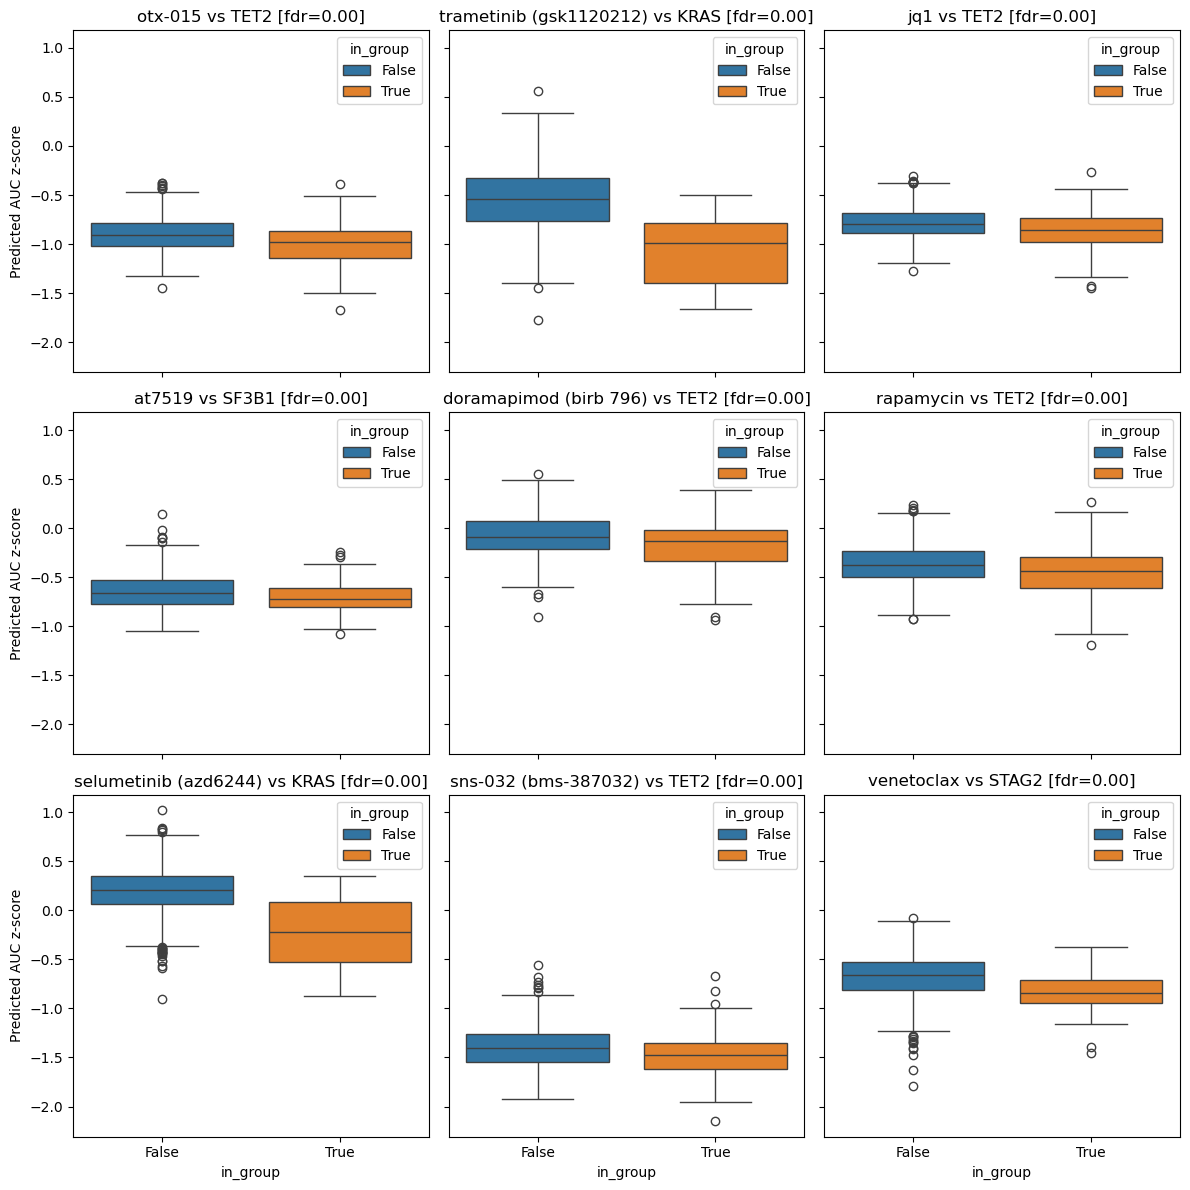

In [93]:
fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in res.sort_values(sort_on, ascending=True).head(9).reset_index(drop=True).iterrows(): 

    mut_group = row.mut_subgroup
    subgroup_ids = mds_muts[lambda x: x[mut_group] == 'POSITIVE']['MLL ID'].unique().tolist()
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug1} vs {mut_group} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

plt.tight_layout()
plt.show() 



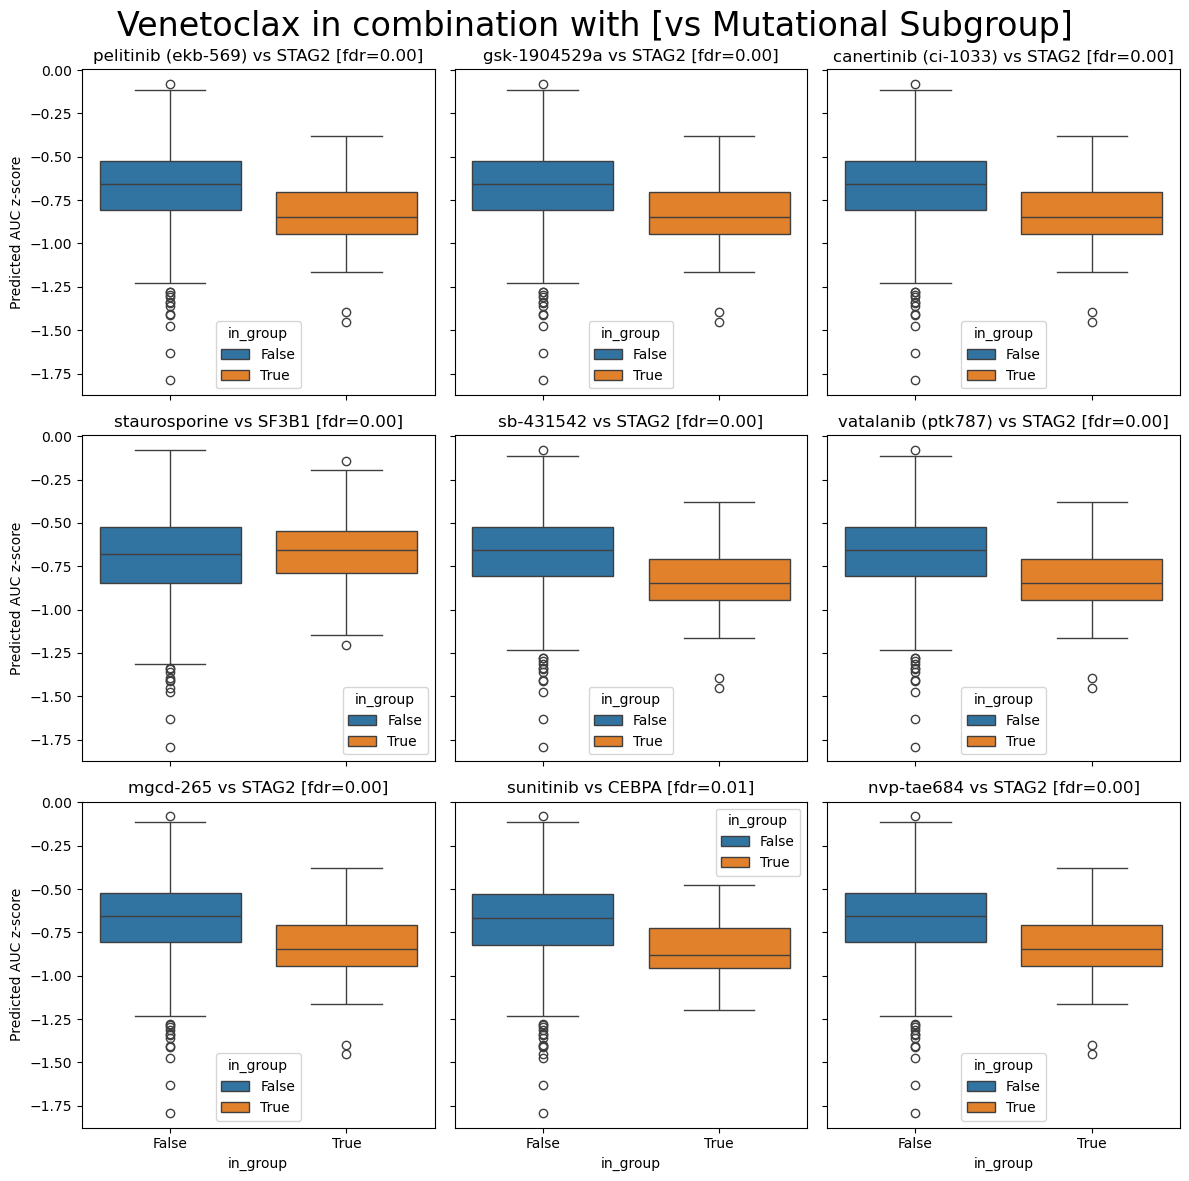

In [94]:
fig, axes = plt.subplots(3,3, figsize=(12, 12), sharey=True, sharex=True)

for i, row in res_ven.sort_values(sort_on, ascending=True).head(9).reset_index(drop=True).iterrows(): 

    mut_group = row.mut_subgroup
    subgroup_ids = mds_muts[lambda x: x[mut_group] == 'POSITIVE']['MLL ID'].unique().tolist()
    tmp = mds_preds[lambda x: (x.inhibitor_1 == row.drug1) & (x.inhibitor_2.isna())].assign(in_group = lambda x: x.id.isin(subgroup_ids))

    axes.flat[i].set_title(f'{row.drug2} vs {mut_group} [fdr={row.fdr:.2f}]')
    sbn.boxplot(data=tmp, x='in_group', y='yhat', hue='in_group', ax=axes.flat[i]) 
    axes.flat[i].set_ylabel('Predicted AUC z-score')

    plt.suptitle('Venetoclax in combination with [vs Mutational Subgroup]', fontsize=24)

plt.tight_layout()
plt.show() 

# BeatAML MDS patient comparison 

In [72]:
mds_subgroup_beataml_annot = pd.read_csv('/mnt/c/Users/natha/Downloads/mds_subgroup_predictions_single_agents-annotated_beataml.csv')

# if beataml_mut_n is 1, set the p-value to nan 
mds_subgroup_beataml_annot = mds_subgroup_beataml_annot.assign(pval = [np.nan if x == 1 else x for x in mds_subgroup_beataml_annot.beataml_mut_n])
mds_subgroup_beataml_annot.head()

,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr,beataml_mean_diff_auc,beataml_pval,beataml_inh_n,beataml_mut_n
0,17-aag (tanespimycin),NaN,-0.456286,0.199902,-0.514691,0.200064,5.0,2.952636,127,ASXL1,0.058405,0.029454,11.508880,0.653033,9.0,5.0
1,at7519,NaN,-0.614395,0.171870,-0.671959,0.179276,5.0,3.357408,127,ASXL1,0.057563,0.010464,-9.224191,0.713317,9.0,5.0
2,axitinib (ag-013736),NaN,0.228539,0.236765,0.165708,0.221709,5.0,2.714098,127,ASXL1,0.062832,0.049318,8.516872,0.765359,9.0,5.0
3,bosutinib (ski-606),NaN,0.371337,0.316472,0.245296,0.283224,5.0,4.103528,127,ASXL1,0.126041,0.001397,-31.884840,0.263378,9.0,5.0
4,ci-1040 (pd184352),NaN,0.233649,0.210242,0.194199,0.193667,5.0,1.924388,127,ASXL1,0.039451,0.202893,3.038588,0.895013,9.0,5.0


In [73]:
df = mds_subgroup_beataml_annot

df = df[lambda x: x.fdr < 0.05]
df = df[lambda x: x.tstat < 0]
df = df[lambda x: x.beataml_mean_diff_auc < 0]

df = df[['drug1', 'mut_subgroup']] 
df = df.groupby('drug1').agg(list).reset_index()

#df.to_csv('/mnt/c/Users/natha/Documents/mds_sensitivity_mutations_by_drug.csv', index=False)
df.head(10).style.hide()


drug1,mut_subgroup
at7519,['SF3B1']
ci-1040 (pd184352),['KRAS']
nvp-tae684,['STAG2']
selumetinib (azd6244),['KRAS']
sns-032 (bms-387032),['SF3B1']
trametinib (gsk1120212),['KRAS']
venetoclax,"['TP53', 'STAG2', 'RUNX1']"


In [74]:
for i in range(1,5): 
    print(i, mds_subgroup_beataml_annot[lambda x: x.beataml_mut_n > i][['mean_diff', 'beataml_mean_diff_auc']].corr('spearman').values[0,1])

1 0.0686054618107537
2 -0.146392471244336
3 -0.21694322011926367
4 0.11538461538461539


/tmp/ipykernel_1917/1486131991.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


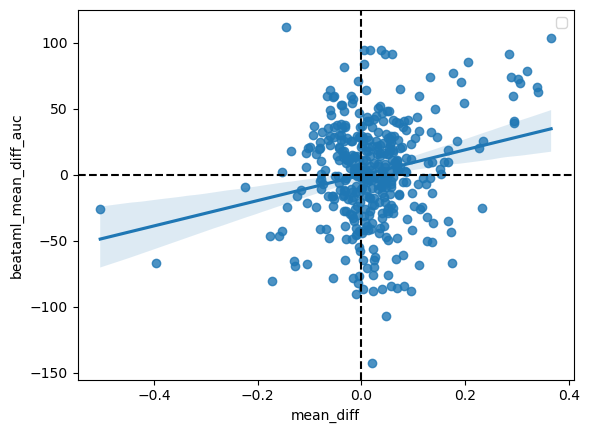

In [75]:
plt.figure() 
sbn.regplot(data=mds_subgroup_beataml_annot[lambda x: x.beataml_mut_n > 0], x='mean_diff', y='beataml_mean_diff_auc')#, hue='beataml_mut_n')
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show() 



In [76]:
-np.log10(0.05)

np.float64(1.3010299956639813)

In [77]:
mds_subgroup_beataml_annot

,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr,beataml_mean_diff_auc,beataml_pval,beataml_inh_n,beataml_mut_n
0,17-aag (tanespimycin),NaN,-0.456286,0.199902,-0.514691,0.200064,5.0,2.952636,127,ASXL1,0.058405,0.029454,11.508880,0.653033,9.0,5.0
1,at7519,NaN,-0.614395,0.171870,-0.671959,0.179276,5.0,3.357408,127,ASXL1,0.057563,0.010464,-9.224191,0.713317,9.0,5.0
2,axitinib (ag-013736),NaN,0.228539,0.236765,0.165708,0.221709,5.0,2.714098,127,ASXL1,0.062832,0.049318,8.516872,0.765359,9.0,5.0
3,bosutinib (ski-606),NaN,0.371337,0.316472,0.245296,0.283224,5.0,4.103528,127,ASXL1,0.126041,0.001397,-31.884840,0.263378,9.0,5.0
4,ci-1040 (pd184352),NaN,0.233649,0.210242,0.194199,0.193667,5.0,1.924388,127,ASXL1,0.039451,0.202893,3.038588,0.895013,9.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692,jq1,NaN,-0.734195,0.239844,-0.804091,0.171354,NaN,1.084481,15,BCOR,0.069896,0.554054,NaN,NaN,NaN,NaN
693,lenvatinib,NaN,-0.032613,0.238273,-0.060749,0.208293,NaN,0.438242,15,BCOR,0.028136,0.834009,NaN,NaN,NaN,NaN
694,venetoclax,NaN,-0.772928,0.259989,-0.687974,0.239090,NaN,-1.211668,15,BCOR,-0.084954,0.506719,NaN,NaN,NaN,NaN
695,otx-015,NaN,-0.820244,0.276217,-0.924296,0.190609,NaN,1.402348,15,BCOR,0.104052,0.440494,NaN,NaN,NaN,NaN


In [78]:
from scipy.stats import spearmanr, kendalltau, pearsonr

df = mds_subgroup_beataml_annot[['mean_diff', 'beataml_mean_diff_auc']].dropna()

print('correlation  between predicted and empirical subgroup differences:')

pc = pearsonr(df.mean_diff, df.beataml_mean_diff_auc)
print(f'\tpearson r: {pc.correlation}')
print(f'\tp-value: {pc.pvalue}')
print() 

sp = spearmanr(df.mean_diff, df.beataml_mean_diff_auc)
print(f'\tspearman rho: {sp.correlation}')
print(f'\tp-value: {sp.pvalue}')
print() 


kt = kendalltau(df.mean_diff, df.beataml_mean_diff_auc)
print(f'\tkendall tau: {kt.correlation}')
print(f'\tp-value: {kt.pvalue}')


correlation  between predicted and empirical subgroup differences:
	pearson r: 0.2216279239753262
	p-value: 8.739362888161773e-06

	spearman rho: 0.09206527414359136
	p-value: 0.06757267406391783

	kendall tau: 0.060739646203200194
	p-value: 0.07145045877675171


In [79]:
mds_subgroup_beataml_annot[['mean_diff', 'beataml_mean_diff_auc']].corr('spearman').values[0,1]

np.float64(0.09206527414359138)

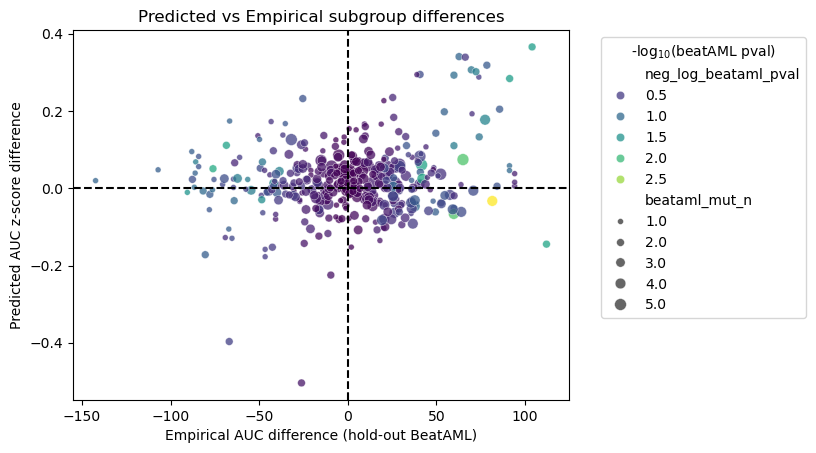

In [80]:
mds_subgroup_beataml_annot = mds_subgroup_beataml_annot.assign(neg_log_beataml_pval = lambda x: -np.log10(x.beataml_pval + 1e-12))

plt.figure() 
sbn.scatterplot(data=mds_subgroup_beataml_annot, y='mean_diff', x='beataml_mean_diff_auc', hue='neg_log_beataml_pval', size='beataml_mut_n', alpha=0.75, palette='viridis')
plt.axvline(0, color='black', linestyle='--')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Predicted AUC z-score difference')
plt.xlabel('Empirical AUC difference (hold-out BeatAML)')
plt.legend(title='-log$_{10}$(beatAML pval)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Predicted vs Empirical subgroup differences')
plt.show() 

In [81]:
mds_subgroup_beataml_annot.head() 

,drug1,drug2,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,pval,tstat,subgroup_n,mut_subgroup,mean_diff,fdr,beataml_mean_diff_auc,beataml_pval,beataml_inh_n,beataml_mut_n,neg_log_beataml_pval
0,17-aag (tanespimycin),NaN,-0.456286,0.199902,-0.514691,0.200064,5.0,2.952636,127,ASXL1,0.058405,0.029454,11.508880,0.653033,9.0,5.0,0.185065
1,at7519,NaN,-0.614395,0.171870,-0.671959,0.179276,5.0,3.357408,127,ASXL1,0.057563,0.010464,-9.224191,0.713317,9.0,5.0,0.146717
2,axitinib (ag-013736),NaN,0.228539,0.236765,0.165708,0.221709,5.0,2.714098,127,ASXL1,0.062832,0.049318,8.516872,0.765359,9.0,5.0,0.116135
3,bosutinib (ski-606),NaN,0.371337,0.316472,0.245296,0.283224,5.0,4.103528,127,ASXL1,0.126041,0.001397,-31.884840,0.263378,9.0,5.0,0.579420
4,ci-1040 (pd184352),NaN,0.233649,0.210242,0.194199,0.193667,5.0,1.924388,127,ASXL1,0.039451,0.202893,3.038588,0.895013,9.0,5.0,0.048171


In [82]:
from math import sqrt
from statistics import NormalDist
from typing import Literal

def power_two_sample_z(
    a_mu: float,
    a_std: float,
    b_mu: float,
    b_std: float,
    n_a: int,
    n_b: int,
    alpha: float = 0.05,
    alternative: Literal["two-sided","larger","smaller"] = "two-sided",
) -> float:
    """
    Analytic power for two-sample z-test with known variances.

    H0: μa = μb
    H1 (two-sided): μa ≠ μb
       (larger):    μa > μb
       (smaller):   μa < μb

    Z = (X̄a - X̄b) / sqrt(σa^2/n_a + σb^2/n_b)
    Under true Δ = μa - μb, Z ~ Normal(κ, 1) with κ = Δ / SE.

    Returns:
        Power in [0,1].
    """
    nd = NormalDist()
    se = sqrt(a_std**2 / n_a + b_std**2 / n_b)
    kappa = (a_mu - b_mu) / se  # noncentrality (mean of Z under H1)

    if alternative == "two-sided":
        zcrit = nd.inv_cdf(1 - alpha / 2.0)
        # Power = P(Z > zcrit - κ) + P(Z < -zcrit - κ),  Z ~ N(0,1)
        return (1 - nd.cdf(zcrit - kappa)) + nd.cdf(-zcrit - kappa)
    elif alternative == "larger":
        zcrit = nd.inv_cdf(1 - alpha)
        return 1 - nd.cdf(zcrit - kappa)
    elif alternative == "smaller":
        zcrit = nd.inv_cdf(1 - alpha)
        return nd.cdf(-zcrit - kappa)
    else:
        raise ValueError("alternative must be 'two-sided', 'larger', or 'smaller'")

In [83]:
mds_subgroup_beataml_annot.sort_values('mean_diff', ascending=True)[['drug1', 'drug2', 'mut_subgroup', 'subgroup_y_mean', 'subgroup_y_std', 'rest_y_mean', 'rest_y_std', 'beataml_inh_n', 'beataml_mut_n']].reset_index(drop=True)

,drug1,drug2,mut_subgroup,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,beataml_inh_n,beataml_mut_n
0,trametinib (gsk1120212),NaN,KRAS,-1.052013,0.349188,-0.548111,0.338388,10.0,2.0
1,selumetinib (azd6244),NaN,KRAS,-0.207054,0.344209,0.189700,0.252938,9.0,2.0
2,trametinib (gsk1120212),NaN,SETBP1,-0.855558,0.309404,-0.557364,0.346749,NaN,NaN
3,trametinib (gsk1120212),NaN,NF1,-0.807234,0.388033,-0.555278,0.344802,NaN,NaN
4,selumetinib (azd6244),NaN,SETBP1,-0.060119,0.335968,0.182508,0.260836,NaN,NaN
...,...,...,...,...,...,...,...,...,...
692,trametinib (gsk1120212),NaN,BCOR,-0.251691,0.467346,-0.568039,0.341333,NaN,NaN
693,trametinib (gsk1120212),NaN,CEBPA,-0.249057,0.362672,-0.567612,0.344443,10.0,2.0
694,vargetef,NaN,KRAS,0.268937,0.220511,-0.070398,0.234903,9.0,2.0
695,nvp-tae684,NaN,KRAS,0.606822,0.195781,0.265981,0.217445,9.0,2.0


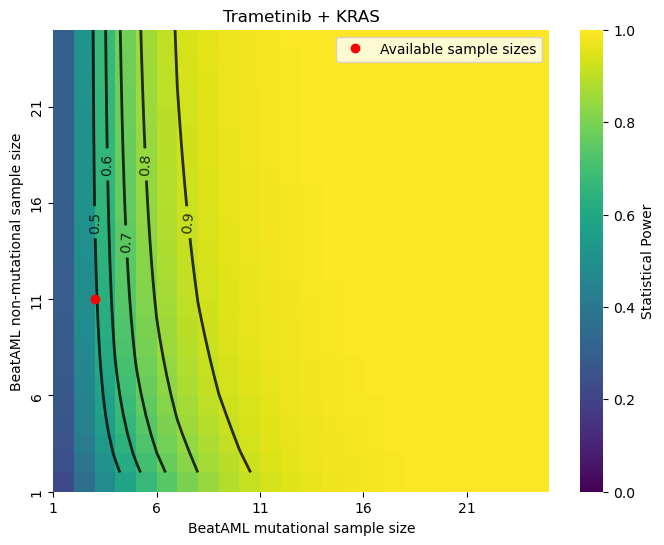

In [84]:
title = 'Trametinib + KRAS'

a_mu = -1.05    # _predicted mutation subgroup mean 
a_std =0.35  # _predicted mutation subgroup std 
b_mu = -0.55  # _predicted non-mutation subgroup mean 
b_std = 0.34 # _predicted non-mutation subgroup std 
true_n_a = 10
true_n_b = 2

nn = 25

n_as_ = np.arange(1,nn)
n_bs = np.arange(1,nn)

powers = []
for n_a_ in n_as_: 
    ps = []
    for n_b in n_bs: 

        n_a = n_b + n_a_

        #if n_a <=  n_b: 
        #    ps.append(None) 

        #else: 
        power = power_two_sample_z(a_mu, a_std, b_mu, b_std, n_a, n_b, alpha=0.05, alternative='two-sided')
        ps.append(power)

    powers.append(ps)

powers = np.array(powers)
pow_df = pd.DataFrame(powers, index=n_as_, columns=n_bs)

plt.figure(figsize=(8, 6))
ax = sbn.heatmap(pow_df.fillna(-1), cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'Statistical Power'})
plt.xlabel('BeatAML mutational sample size')
plt.ylabel('BeatAML non-mutational sample size')

# add contour lines 
X, Y = np.meshgrid(n_bs, n_as_)
contours = plt.contour(X, Y, powers, levels=[0.5, 0.6, 0.7, 0.8, 0.9], colors='k', linewidths=2, alpha=0.8)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f')

# invert y-axis so 1 is at the bottom
ax.invert_yaxis()

# space out tick labels
plt.xticks(np.arange(0, nn, nn//5), np.arange(1, nn+1, nn//5))
plt.yticks(np.arange(0, nn, nn//5), np.arange(1, nn+1, nn//5))

plt.plot(true_n_b, true_n_a, 'ro', label='Available sample sizes')
plt.title(title)
plt.legend()

plt.show()


In [85]:
# TODO: how many samples are necessary to detect a given effect size? 

In [86]:
subset = mds_subgroup_beataml_annot.sort_values('tstat', ascending=True)[['subgroup_y_mean', 'subgroup_y_std', 'rest_y_mean', 'rest_y_std', 'beataml_inh_n', 'beataml_mut_n']].reset_index(drop=True).dropna()

power = [] 
for i,row in subset.iterrows(): 
    power.append(power_two_sample_z(row.subgroup_y_mean, row.subgroup_y_std, row.rest_y_mean, row.rest_y_std, n_a=row.beataml_inh_n, n_b=row.beataml_mut_n, alpha=0.05, alternative='two-sided'))

power = pd.Series(power)
power.name = 'power'

subset = subset.assign(power = power)
subset.head(25) 



,subgroup_y_mean,subgroup_y_std,rest_y_mean,rest_y_std,beataml_inh_n,beataml_mut_n,power
0,-1.000383,0.211172,-0.892591,0.177855,7.0,3.0,0.131641
1,-1.052013,0.349188,-0.548111,0.338388,10.0,2.0,0.480984
2,-0.858132,0.190837,-0.781696,0.161692,7.0,3.0,0.099306
3,-0.706099,0.145817,-0.642158,0.188431,9.0,3.0,0.083589
4,-0.453352,0.238883,-0.361766,0.202476,9.0,4.0,0.109631
5,-0.207054,0.344209,0.189700,0.252938,9.0,2.0,0.463086
6,-1.476590,0.207549,-1.394049,0.218498,9.0,4.0,0.097826
7,-0.837604,0.226117,-0.679465,0.237408,8.0,1.0,0.096757
8,-0.452173,0.223270,-0.299858,0.203578,9.0,1.0,0.108206
9,-1.007815,0.226909,-0.908073,0.183886,7.0,3.0,0.113073


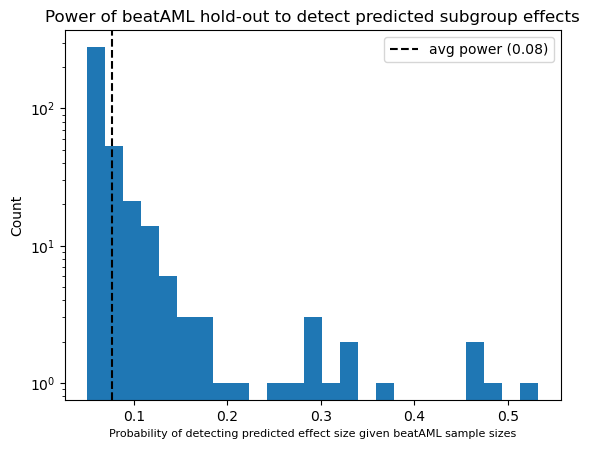

In [87]:
plt.figure()
plt.hist(power, bins=25)
plt.axvline(np.mean(power), color='black', linestyle='--', label=f'avg power ({np.mean(power):.2f})')
plt.xlabel('Probability of detecting predicted effect size given beatAML sample sizes', fontsize=8)
plt.yscale('log')
plt.legend()
plt.title('Power of beatAML hold-out to detect predicted subgroup effects')
plt.ylabel('Count')
plt.show()


In [88]:
mds_subgroup_beataml_annot.sort_values('tstat', ascending=True)[['drug1', 'mut_subgroup','mean_diff', 'tstat', 'subgroup_n', 'beataml_mean_diff_auc', 'fdr', 'beataml_pval']].head(35)

,drug1,mut_subgroup,mean_diff,tstat,subgroup_n,beataml_mean_diff_auc,fdr,beataml_pval
449,otx-015,TET2,-0.107792,-6.106502,182,5.841552,0.000002,0.918965
320,trametinib (gsk1120212),KRAS,-0.503902,-5.706693,17,-26.161023,0.000825,0.649153
446,jq1,TET2,-0.076435,-4.785476,182,32.339186,0.000176,0.461843
452,at7519,SF3B1,-0.063942,-4.713482,197,-15.877121,0.000187,0.544965
434,rapamycin,TET2,-0.091585,-4.580374,182,36.667182,0.000346,0.321985
314,selumetinib (azd6244),KRAS,-0.396754,-4.580273,17,-66.940002,0.004109,0.284017
435,sns-032 (bms-387032),TET2,-0.082541,-4.500103,182,19.278464,0.000383,0.239732
284,venetoclax,STAG2,-0.158139,-4.420955,44,-46.681029,0.001300,0.310848
267,pelitinib (ekb-569),STAG2,-0.152314,-4.350381,44,1.957312,0.001536,0.942357
244,otx-015,SRSF2,-0.099742,-4.010394,93,20.971805,0.002064,0.713010


In [89]:
mds_subgroup_beataml_annot.sort_values('tstat', ascending=True)[['drug1', 'mut_subgroup','mean_diff', 'tstat', 'subgroup_n', 'beataml_mean_diff_auc', 'fdr', 'beataml_pval']]\
    [lambda x: (x.beataml_mean_diff_auc < 0) & (x.beataml_pval < 0.4) & (x.fdr < 0.05) & (x.tstat < 0)].style.hide()

drug1,mut_subgroup,mean_diff,tstat,subgroup_n,beataml_mean_diff_auc,fdr,beataml_pval
selumetinib (azd6244),KRAS,-0.396754,-4.580273,17,-66.940002,0.004109,0.284017
venetoclax,STAG2,-0.158139,-4.420955,44,-46.681029,0.001300,0.310848
sns-032 (bms-387032),SF3B1,-0.055922,-3.346898,197,-16.302524,0.009932,0.355165
nvp-tae684,STAG2,-0.129547,-3.046079,44,-65.380154,0.031166,0.231661


In [90]:
mds_subgroup_beataml_annot.sort_values('tstat', ascending=True)[['drug1', 'mut_subgroup','mean_diff', 'tstat', 'subgroup_n', 'beataml_mean_diff_auc', 'fdr', 'beataml_pval']]\
    [lambda x: (x.mut_subgroup == 'STAG2') & (x.fdr < 0.05) & (x.mean_diff < 0)].style.hide()

drug1,mut_subgroup,mean_diff,tstat,subgroup_n,beataml_mean_diff_auc,fdr,beataml_pval
venetoclax,STAG2,-0.158139,-4.420955,44,-46.681029,0.001300,0.310848
pelitinib (ekb-569),STAG2,-0.152314,-4.350381,44,1.957312,0.001536,0.942357
nvp-tae684,STAG2,-0.129547,-3.046079,44,-65.380154,0.031166,0.231661


In [91]:
mds_subgroup_beataml_annot.sort_values('tstat', ascending=True)[['drug1', 'mut_subgroup','mean_diff', 'tstat', 'subgroup_n', 'beataml_mean_diff_auc', 'fdr', 'beataml_pval']]\
    [lambda x: (x.beataml_mean_diff_auc > 0) & (x.mean_diff > 0)  & (x.drug1 == 'venetoclax')].style.hide()

drug1,mut_subgroup,mean_diff,tstat,subgroup_n,beataml_mean_diff_auc,fdr,beataml_pval
venetoclax,SF3B1,0.029857,1.617494,197,15.743510,0.325427,0.666565
venetoclax,KRAS,0.110262,1.660027,17,59.881798,0.340024,0.057474
